In [1]:
import os
os.chdir("/Users/yesicarb/Desktop/UIE/3º Curso/2 SEM/PROYECTO/emotion/multimodal_emotion")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords

df = pd.read_csv("data/processed/labels.csv")
print(df.shape)
df.head()

(4869, 4)


[nltk_data] Downloading package punkt to /Users/yesicarb/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yesicarb/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/yesicarb/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,id,label,text,image_path
0,1,neutral,How I feel today #legday #jelly #aching #gym,data/raw/data/1.jpg
1,2,neutral,grattis min griskulting!!!???? va bara tvungen...,data/raw/data/2.jpg
2,3,neutral,RT @polynminion: The moment I found my favouri...,data/raw/data/3.jpg
3,4,positive,#escort We have a young and energetic team and...,data/raw/data/4.jpg
4,5,positive,"RT @chrisashaffer: Went to SSC today to be a ""...",data/raw/data/5.jpg


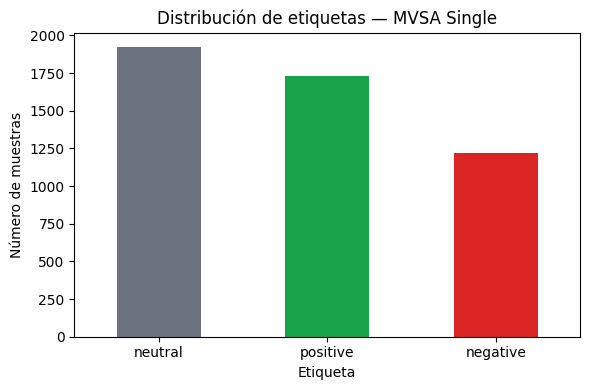

label
neutral     1921
positive    1731
negative    1217
Name: count, dtype: int64


In [2]:
#Distribución de clases
fig, ax = plt.subplots(figsize=(6, 4))
colors = {'positive': '#16a34a', 'neutral': '#6b7280', 'negative': '#dc2626'}
df['label'].value_counts().plot(
    kind='bar', ax=ax,
    color=[colors[l] for l in df['label'].value_counts().index]
)
ax.set_title('Distribución de etiquetas — MVSA Single')
ax.set_xlabel('Etiqueta')
ax.set_ylabel('Número de muestras')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('results/figures/class_distribution.png', dpi=150)
plt.show()
print(df['label'].value_counts())

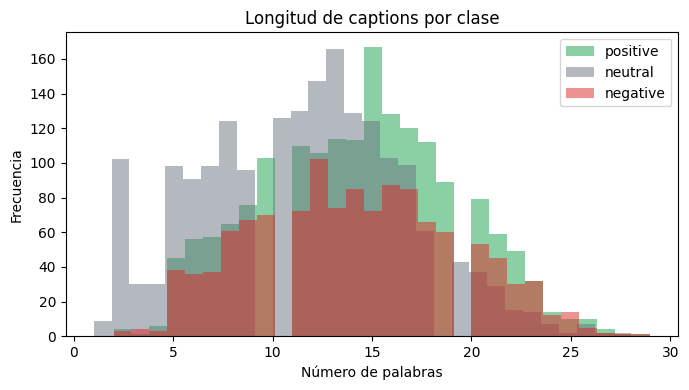

Media:  13.1 palabras
Máximo: 29 palabras
Mínimo: 1 palabras


In [3]:
#Longitud de captions:
df['caption_len'] = df['text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(7, 4))
for label, color in colors.items():
    subset = df[df['label'] == label]['caption_len']
    ax.hist(subset, bins=30, alpha=0.5, label=label, color=color)
ax.set_title('Longitud de captions por clase')
ax.set_xlabel('Número de palabras')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/caption_length.png', dpi=150)
plt.show()

print(f"Media:  {df['caption_len'].mean():.1f} palabras")
print(f"Máximo: {df['caption_len'].max()} palabras")
print(f"Mínimo: {df['caption_len'].min()} palabras")

In [4]:
#Top 10 palabras por clase:
stop = set(stopwords.words('english'))

for label in ['positive', 'negative', 'neutral']:
    texts = df[df['label'] == label]['text'].tolist()
    words = [
        w.lower() for t in texts
        for w in str(t).split()
        if w.lower() not in stop and w.isalpha() and len(w) > 2
    ]
    top10 = Counter(words).most_common(10)
    print(f"\nTop 10 palabras — {label}:")
    for word, count in top10:
        print(f"  {word}: {count}")


Top 10 palabras — positive:
  love: 95
  happy: 88
  day: 80
  new: 72
  like: 50
  get: 46
  one: 43
  much: 36
  best: 36
  birthday: 36

Top 10 palabras — negative:
  like: 43
  http: 33
  man: 23
  got: 23
  get: 21
  abandoned: 21
  still: 20
  last: 20
  black: 19
  take: 19

Top 10 palabras — neutral:
  take: 74
  new: 62
  black: 56
  get: 43
  feeling: 39
  like: 37
  distressed: 33
  one: 31
  full: 31
  cut: 27
